# Fundamentos de Evaluación de Modelos
## Bloque A — El puente entre Preprocesamiento y Minería de Datos

> Antes de entrenar el primer modelo predictivo, necesitamos responder una pregunta que aplica  
> **sin importar el algoritmo que usemos después** (árbol de decisión, KNN, regresión, red neuronal...):  
> **¿cómo sabemos si el modelo realmente aprendió, o solo memorizó?**

---

### Contenido

| # | Tema | Pregunta que responde |
|---|---|---|
| 1 | División Train/Test | ¿Cómo evalúo un modelo con datos que nunca vio? |
| 2 | Overfitting y Underfitting | ¿Por qué un modelo "perfecto" en entrenamiento puede ser malo en producción? |
| 3 | Conjunto de Validación | ¿Cómo ajusto hiperparámetros sin "hacer trampa" con el test? |
| 4 | Validación Cruzada (K-Fold) | ¿Cómo obtengo una evaluación más confiable que un solo split? |
| 5 | Curvas de Aprendizaje | ¿Necesito más datos, o el problema es el modelo? |


---
## 0. Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, LeaveOneOut,
    cross_val_score, learning_curve
)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_classification

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
np.random.seed(42)
print('✓ Listo.')

✓ Listo.


---
# 1. División Train / Test

**Definición:** Separar el dataset en dos subconjuntos disjuntos:
- **Conjunto de entrenamiento (train):** con el que el modelo *aprende* los patrones
- **Conjunto de prueba (test):** que el modelo **nunca ve durante el entrenamiento**, usado únicamente para medir qué tan bien generaliza

**¿Por qué es necesario?** Si evaluamos el modelo con los mismos datos que usó para aprender, no sabemos si realmente entendió el patrón subyacente o si simplemente **memorizó** las respuestas — como un estudiante que memoriza las respuestas de un examen de práctica en vez de entender el tema.

**Proporciones típicas:** 70/30, 80/20 o 90/10 (train/test), dependiendo del tamaño del dataset. Con pocos datos, se reserva menos para test.


In [2]:
# Dataset simple: 10 estudiantes con horas de estudio y si aprobaron
df = pd.DataFrame({
    'Estudiante':     [f'E{i}' for i in range(1, 11)],
    'Horas_Estudio':  [2, 5, 1, 8, 3, 9, 4, 7, 2, 6],
    'Aprobo':         [0, 1, 0, 1, 0, 1, 1, 1, 0, 1]
})

print('Dataset completo (10 estudiantes):')
print(df)

X = df[['Horas_Estudio']]
y = df['Aprobo']

# Split 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f'\nTrain: {len(X_train)} estudiantes ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test:  {len(X_test)} estudiantes ({len(X_test)/len(df)*100:.0f}%)')

print('\nÍndices que quedaron en train:', X_train.index.tolist())
print('Índices que quedaron en test: ', X_test.index.tolist())

Dataset completo (10 estudiantes):
  Estudiante  Horas_Estudio  Aprobo
0         E1              2       0
1         E2              5       1
2         E3              1       0
3         E4              8       1
4         E5              3       0
5         E6              9       1
6         E7              4       1
7         E8              7       1
8         E9              2       0
9        E10              6       1

Train: 7 estudiantes (70%)
Test:  3 estudiantes (30%)

Índices que quedaron en train: [0, 7, 2, 9, 4, 3, 6]
Índices que quedaron en test:  [8, 1, 5]


### `random_state`: reproducibilidad del split

`train_test_split` mezcla los datos aleatoriamente antes de dividirlos. El parámetro `random_state`  
fija esa "semilla" aleatoria — usar el mismo valor garantiza que **el split sea idéntico cada vez que se ejecuta el código**, algo esencial para poder reproducir resultados y comparar modelos de forma justa.


In [3]:
# Sin fijar random_state, cada ejecución da un split distinto
print('Ejecución 1 (sin random_state):', train_test_split(X, y, test_size=0.3)[0].index.tolist())
print('Ejecución 2 (sin random_state):', train_test_split(X, y, test_size=0.3)[0].index.tolist())
print()
print('Ejecución 1 (random_state=42):', train_test_split(X, y, test_size=0.3, random_state=42)[0].index.tolist())
print('Ejecución 2 (random_state=42):', train_test_split(X, y, test_size=0.3, random_state=42)[0].index.tolist())

Ejecución 1 (sin random_state): [0, 7, 2, 9, 4, 3, 6]
Ejecución 2 (sin random_state): [5, 3, 4, 7, 9, 6, 2]

Ejecución 1 (random_state=42): [0, 7, 2, 9, 4, 3, 6]
Ejecución 2 (random_state=42): [0, 7, 2, 9, 4, 3, 6]


### Split estratificado (`stratify`)

En problemas de **clasificación**, si una clase es minoritaria (ej. 10% positivos, 90% negativos),  
un split aleatorio simple puede dejar por azar muy pocos —o ningún— ejemplo de la clase minoritaria en el test.  
El parámetro `stratify` obliga a que **la proporción de clases se mantenga igual** en train y en test.


In [6]:
# Dataset desbalanceado: 90 negativos, 10 positivos
X_desb, y_desb = make_classification(
    n_samples=100, n_features=2, n_informative=2, n_redundant=0,
    weights=[0.9, 0.1], random_state=42
)

print('Proporción de clases en el dataset completo:')
print(pd.Series(y_desb).value_counts(normalize=True).round(3))

# Split SIN estratificar
_, _, y_train_sin, y_test_sin = train_test_split(X_desb, y_desb, test_size=0.2, random_state=1)
print('\nProporción en TEST sin estratificar:')
print(pd.Series(y_test_sin).value_counts(normalize=True).round(3))

# Split CON estratificar
_, _, y_train_con, y_test_con = train_test_split(X_desb, y_desb, test_size=0.2, random_state=1, stratify=y_desb)
print('\nProporción en TEST con estratificar (stratify=y):')
print(pd.Series(y_test_con).value_counts(normalize=True).round(3))

Proporción de clases en el dataset completo:
0    0.9
1    0.1
Name: proportion, dtype: float64

Proporción en TEST sin estratificar:
0    0.95
1    0.05
Name: proportion, dtype: float64

Proporción en TEST con estratificar (stratify=y):
0    0.9
1    0.1
Name: proportion, dtype: float64


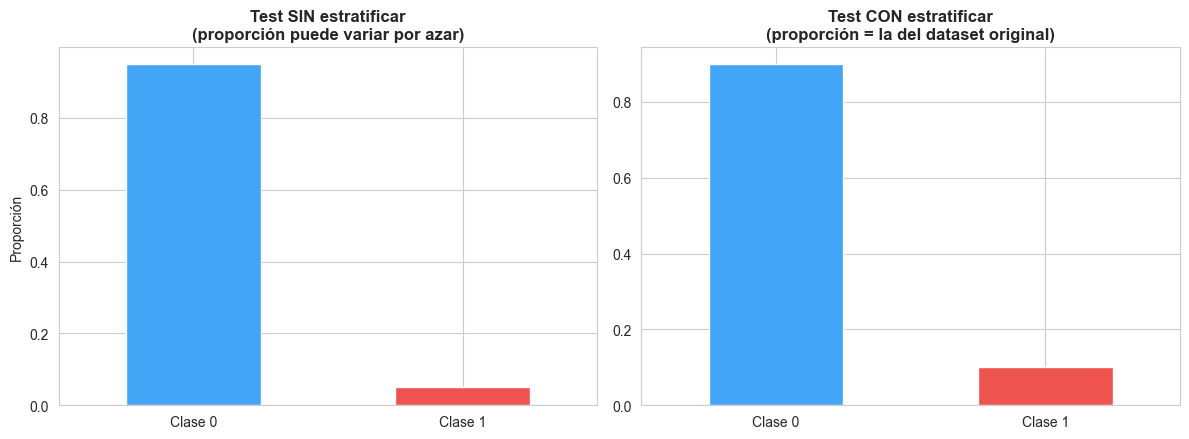

In [7]:
# Figura: proporción de clases con y sin estratificar
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

pd.Series(y_test_sin).value_counts(normalize=True).sort_index().plot(
    kind='bar', ax=axes[0], color=['#42A5F5', '#EF5350'])
axes[0].set_title('Test SIN estratificar\n(proporción puede variar por azar)', fontweight='bold')
axes[0].set_ylabel('Proporción')
axes[0].set_xticklabels(['Clase 0', 'Clase 1'], rotation=0)

pd.Series(y_test_con).value_counts(normalize=True).sort_index().plot(
    kind='bar', ax=axes[1], color=['#42A5F5', '#EF5350'])
axes[1].set_title('Test CON estratificar\n(proporción = la del dataset original)', fontweight='bold')
axes[1].set_xticklabels(['Clase 0', 'Clase 1'], rotation=0)

plt.tight_layout()
plt.show()

---
# 2. Overfitting y Underfitting

**Underfitting (subajuste):** el modelo es **demasiado simple** para capturar el patrón real de los datos.  
Falla tanto en entrenamiento como en test — el modelo "no aprendió lo suficiente".

**Overfitting (sobreajuste):** el modelo es **demasiado complejo** y termina memorizando el ruido específico  
de los datos de entrenamiento, en lugar de aprender el patrón general. Funciona muy bien en entrenamiento  
pero mal en test — el modelo "memorizó en vez de aprender".

**El punto óptimo (buen ajuste)** está en un punto intermedio de complejidad, donde el modelo captura  
el patrón real sin memorizar el ruido.


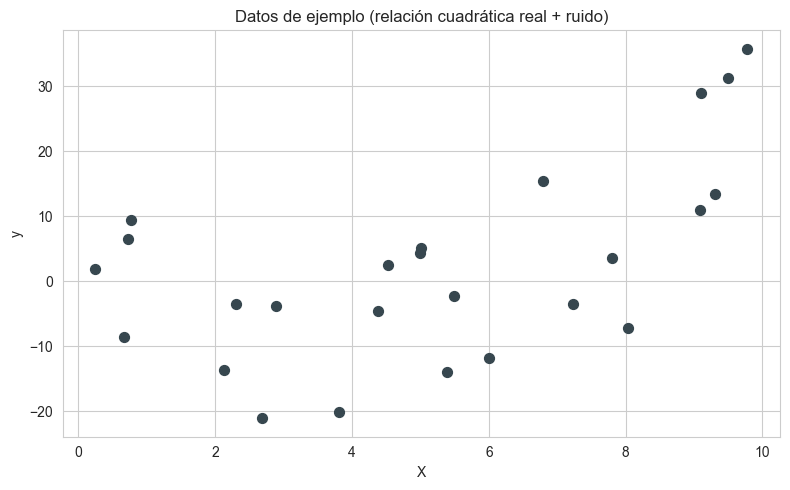

In [8]:
# Datos sintéticos: relación cuadrática con ruido
np.random.seed(7)
X_sim = np.sort(np.random.uniform(0, 10, 25)).reshape(-1, 1)
y_sim = 2 + 0.5 * X_sim.ravel()**2 - 3 * X_sim.ravel() + np.random.normal(0, 8, 25)

plt.figure(figsize=(8, 5))
plt.scatter(X_sim, y_sim, color='#37474F', s=50)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Datos de ejemplo (relación cuadrática real + ruido)')
plt.tight_layout()
plt.show()

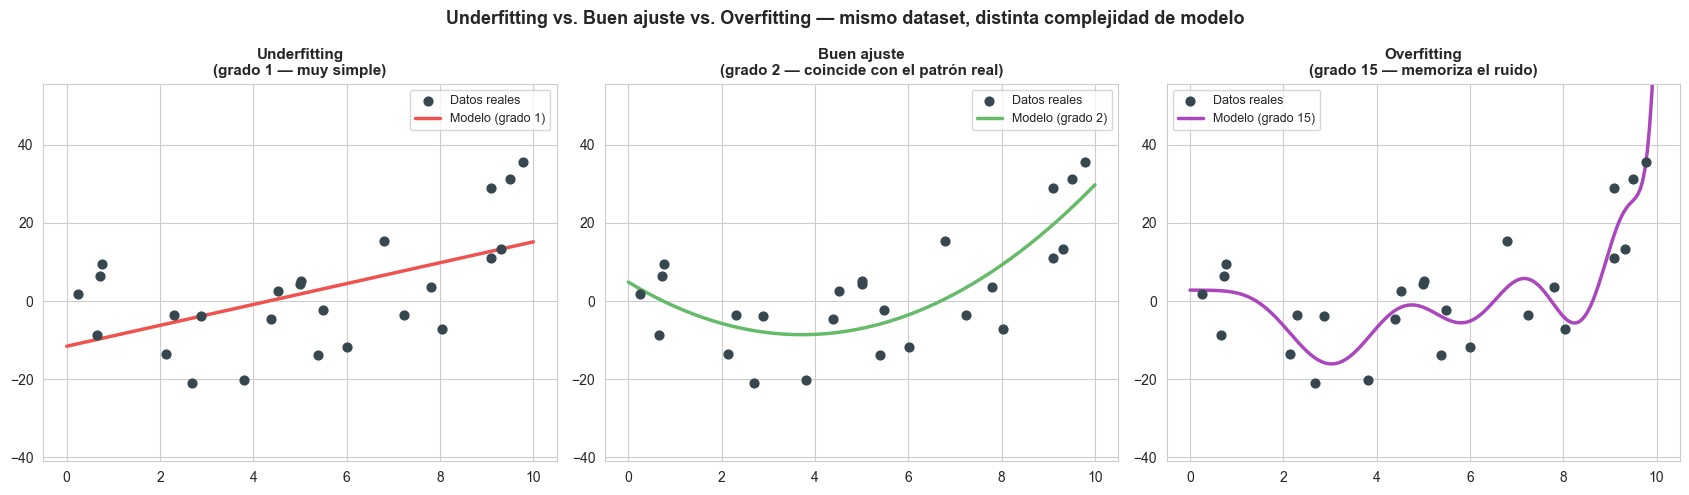

In [9]:
# Ajustar 3 modelos de distinta complejidad: grado 1 (lineal), grado 2 (correcto), grado 15 (muy complejo)
grados = [1, 2, 15]
titulos = ['Underfitting\n(grado 1 — muy simple)', 'Buen ajuste\n(grado 2 — coincide con el patrón real)', 'Overfitting\n(grado 15 — memoriza el ruido)']
colores = ['#EF5350', '#66BB6A', '#AB47BC']

X_plot = np.linspace(0, 10, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, grado, titulo, color in zip(axes, grados, titulos, colores):
    modelo = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    modelo.fit(X_sim, y_sim)
    y_plot = modelo.predict(X_plot)

    ax.scatter(X_sim, y_sim, color='#37474F', s=40, zorder=3, label='Datos reales')
    ax.plot(X_plot, y_plot, color=color, linewidth=2.5, label=f'Modelo (grado {grado})')
    ax.set_ylim(y_sim.min()-20, y_sim.max()+20)
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Underfitting vs. Buen ajuste vs. Overfitting — mismo dataset, distinta complejidad de modelo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Diagnóstico numérico: comparar error en train vs. test

Visualmente es fácil detectar over/underfitting con una sola variable — en la práctica (muchas variables)  
no podemos "ver" la curva. Por eso se compara el **error en entrenamiento vs. el error en test**:

| Situación | Error en train | Error en test |
|---|---|---|
| Underfitting | Alto | Alto (similar al de train) |
| Buen ajuste | Bajo | Bajo (similar al de train) |
| Overfitting | Muy bajo | Alto (mucho mayor que train) |


> **Nota — esto aplica a cualquier métrica, no solo al error:**
> El diagnóstico nunca está en el valor absoluto de la métrica, sino en la **brecha entre train y test**.
> Con métricas donde *menor es mejor* (error, MSE, RMSE): overfitting = train muy bajo, test alto.
> Con métricas donde *mayor es mejor* (accuracy, R², F1): overfitting = train muy alto, test bajo.
> Una brecha grande entre ambos, sin importar el sentido de la métrica, es la señal de alerta.


In [10]:
# Split train/test para medir el error de cada modelo de forma honesta
X_tr, X_te, y_tr, y_te = train_test_split(X_sim, y_sim, test_size=0.3, random_state=42)

print(f'{"Grado":<8}{"Error en TRAIN":>18}{"Error en TEST":>18}')
print('-' * 44)

for grado in [1, 2, 4, 8, 15]:
    modelo = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    modelo.fit(X_tr, y_tr)

    error_train = mean_squared_error(y_tr, modelo.predict(X_tr))
    error_test  = mean_squared_error(y_te, modelo.predict(X_te))

    print(f'{grado:<8}{error_train:>18.1f}{error_test:>18.1f}')

Grado       Error en TRAIN     Error en TEST
--------------------------------------------
1                    142.7             154.9
2                     75.0             124.7
4                     43.9             199.8
8                     34.9            1223.0
15                    29.4             235.7


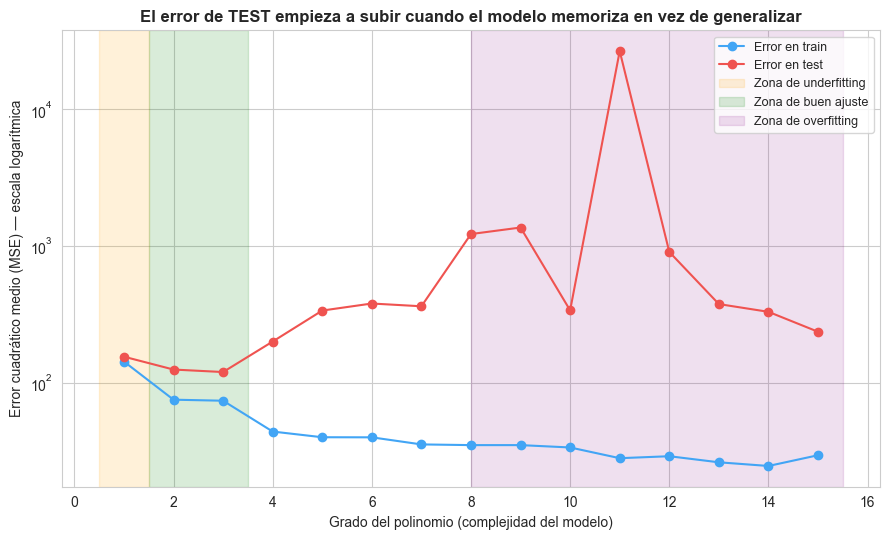

In [11]:
# Figura: error de train y test según la complejidad del modelo
grados_rango = range(1, 16)
errores_train, errores_test = [], []

for grado in grados_rango:
    modelo = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    modelo.fit(X_tr, y_tr)
    errores_train.append(mean_squared_error(y_tr, modelo.predict(X_tr)))
    errores_test.append(mean_squared_error(y_te, modelo.predict(X_te)))

plt.figure(figsize=(9, 5.5))
plt.plot(list(grados_rango), errores_train, 'o-', color='#42A5F5', label='Error en train')
plt.plot(list(grados_rango), errores_test,  'o-', color='#EF5350', label='Error en test')
plt.axvspan(0.5, 1.5, color='orange', alpha=0.15, label='Zona de underfitting')
plt.axvspan(1.5, 3.5, color='green', alpha=0.15, label='Zona de buen ajuste')
plt.axvspan(8, 15.5, color='purple', alpha=0.12, label='Zona de overfitting')
plt.xlabel('Grado del polinomio (complejidad del modelo)')
plt.yscale('log')
plt.ylabel('Error cuadrático medio (MSE) — escala logarítmica')
plt.title('El error de TEST empieza a subir cuando el modelo memoriza en vez de generalizar', fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Bias y Varianza (Bias-Variance Tradeoff)

Overfitting y underfitting son la manifestación **observable** (la brecha train/test).  
**Bias** y **varianza** son la explicación de **por qué ocurren**.

**Bias (sesgo):** error que viene de que el modelo es **demasiado simple** para capturar la relación real  
de los datos. Un modelo con alto bias hace suposiciones muy rígidas y no logra ajustarse ni siquiera  
a los datos de entrenamiento.

**Varianza (variance):** error que viene de que el modelo es **demasiado sensible** a las particularidades  
del conjunto de entrenamiento específico. Un modelo con alta varianza cambia mucho si se entrena con  
datos ligeramente distintos — memoriza el ruido en vez del patrón general.

| | Bias | Varianza |
|---|---|---|
| **Underfitting** | Alto | Bajo |
| **Buen ajuste** | Bajo | Bajo |
| **Overfitting** | Bajo | Alto |

> Alto bias = el modelo es demasiado rígido para aprender el patrón.  
> Alta varianza = el modelo es demasiado flexible y aprende hasta el ruido.  
> El objetivo no es eliminar ambos, sino encontrar el punto que minimiza la **suma** de los dos — el *trade-off* bias-varianza.


### Haciendo tangible la varianza: reentrenar sobre distintas muestras

Para **ver** la varianza, entrenamos el mismo modelo muchas veces, cada vez sobre una muestra distinta  
(obtenida por *bootstrap*: remuestreo con reemplazo) de los mismos datos. Si el modelo tiene **alta varianza**,  
las curvas resultantes se verán muy distintas entre sí. Si tiene **bajo varianza**, las curvas serán casi idénticas.


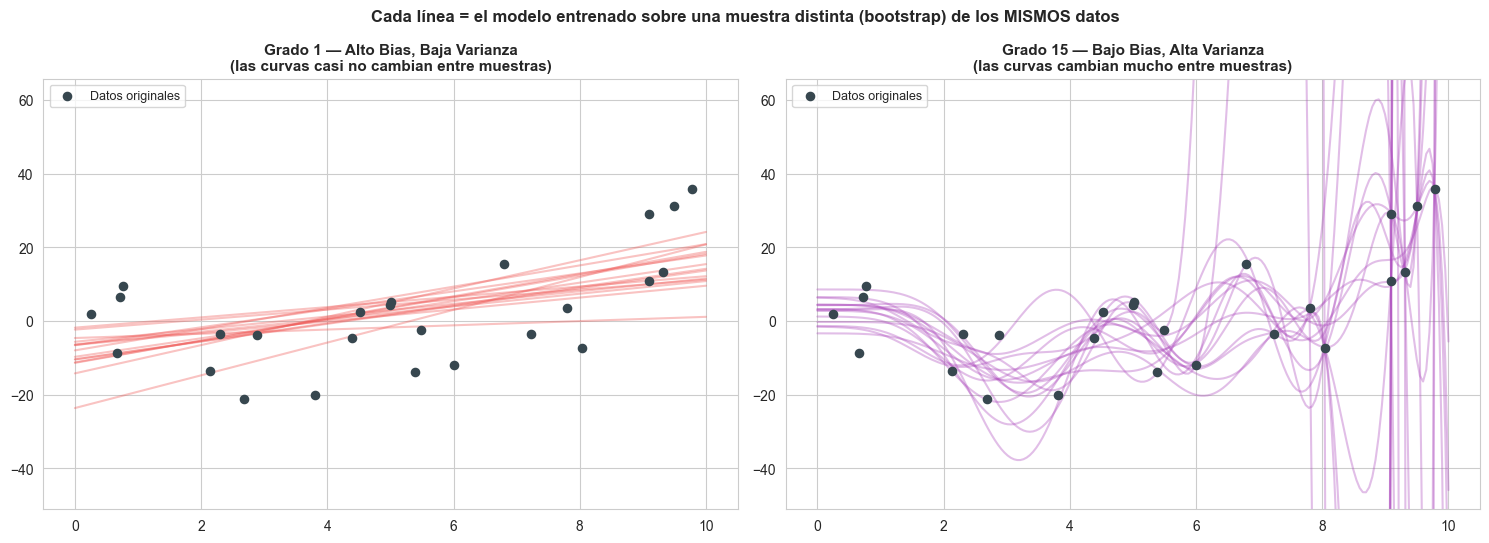

Grado 1: las 15 líneas rojas casi se superponen → BAJA varianza (pero todas lejos del patrón real → ALTO bias)
Grado 15: las 15 líneas moradas divergen mucho entre sí → ALTA varianza


In [12]:
# Bootstrap: 15 remuestreos de los mismos datos, ajustando grado 1 (alto bias) vs grado 15 (alta varianza)
np.random.seed(0)
n_resamples = 15

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, grado, titulo, color in zip(
    axes, [1, 15],
    ['Grado 1 — Alto Bias, Baja Varianza\n(las curvas casi no cambian entre muestras)',
     'Grado 15 — Bajo Bias, Alta Varianza\n(las curvas cambian mucho entre muestras)'],
    ['#EF5350', '#AB47BC']
):
    ax.scatter(X_sim, y_sim, color='#37474F', s=35, zorder=5, label='Datos originales')

    for _ in range(n_resamples):
        idx_boot = np.random.choice(len(X_sim), size=len(X_sim), replace=True)
        X_boot, y_boot = X_sim[idx_boot], y_sim[idx_boot]

        modelo_boot = make_pipeline(PolynomialFeatures(grado), LinearRegression())
        modelo_boot.fit(X_boot, y_boot)
        y_pred_boot = modelo_boot.predict(X_plot)

        ax.plot(X_plot, y_pred_boot, color=color, alpha=0.35, linewidth=1.5)

    ax.set_ylim(y_sim.min()-30, y_sim.max()+30)
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.legend(fontsize=9, loc='upper left')

plt.suptitle('Cada línea = el modelo entrenado sobre una muestra distinta (bootstrap) de los MISMOS datos',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Grado 1: las 15 líneas rojas casi se superponen → BAJA varianza (pero todas lejos del patrón real → ALTO bias)')
print('Grado 15: las 15 líneas moradas divergen mucho entre sí → ALTA varianza')

### La curva teórica del trade-off

De forma esquemática (no calculada de los datos anteriores, sino como referencia conceptual):


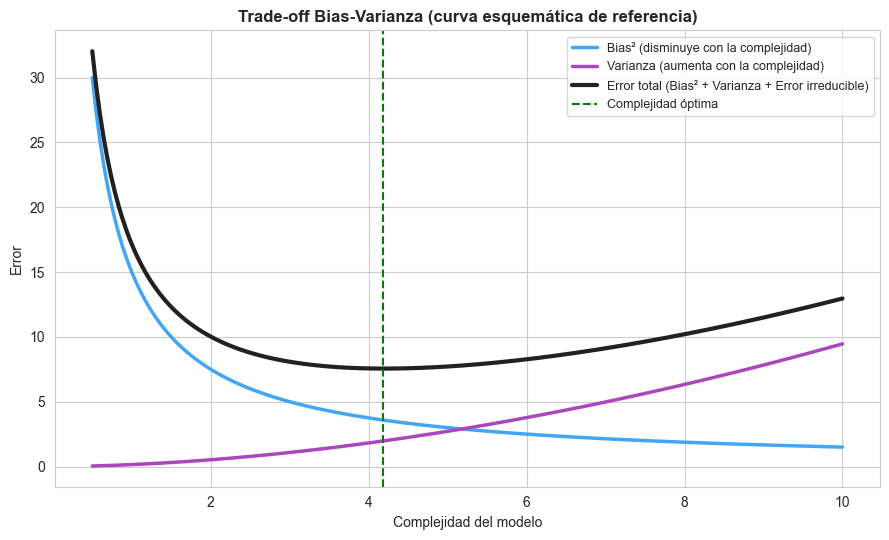

In [13]:
# Curva esquemática del trade-off bias-varianza (ilustrativa, no calculada empíricamente)
complejidad = np.linspace(0.5, 10, 200)
bias2      = 15 / complejidad
varianza   = 0.15 * complejidad**1.8
error_irreducible = np.full_like(complejidad, 2)
error_total = bias2 + varianza + error_irreducible

plt.figure(figsize=(9, 5.5))
plt.plot(complejidad, bias2, color='#42A5F5', linewidth=2.5, label='Bias² (disminuye con la complejidad)')
plt.plot(complejidad, varianza, color='#AB47BC', linewidth=2.5, label='Varianza (aumenta con la complejidad)')
plt.plot(complejidad, error_total, color='#212121', linewidth=3, label='Error total (Bias² + Varianza + Error irreducible)')

idx_min = np.argmin(error_total)
plt.axvline(complejidad[idx_min], color='green', linestyle='--', linewidth=1.5, label='Complejidad óptima')

plt.xlabel('Complejidad del modelo')
plt.ylabel('Error')
plt.title('Trade-off Bias-Varianza (curva esquemática de referencia)', fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
# 3. Conjunto de Validación (Train / Validation / Test)

**El problema:** si usamos el conjunto de **test** repetidamente para probar distintos hiperparámetros  
(ej. probar grado 2, luego grado 3, luego grado 4...) y nos quedamos con el que mejor resultado da en test,  
**estamos filtrando información del test hacia el proceso de decisión** — el test deja de ser una medida honesta  
de qué tan bien generaliza el modelo con datos nunca vistos.

**La solución:** dividir en **tres** conjuntos:

| Conjunto | Uso | Se toca cuántas veces |
|---|---|---|
| **Train** | Entrenar el modelo | Muchas |
| **Validation** | Comparar hiperparámetros y elegir el mejor modelo | Muchas |
| **Test** | Medición **final** y honesta del modelo ya elegido | **Solo una vez**, al final |

**Proporciones típicas:** 60% train / 20% validation / 20% test.


In [14]:
# División en 3 partes: primero separamos test, luego separamos validation del resto
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_sim, y_sim, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42  # 0.25 de 80% = 20% del total
)

print(f'Train:      {len(X_train)} muestras ({len(X_train)/len(X_sim)*100:.0f}%)')
print(f'Validation: {len(X_val)} muestras ({len(X_val)/len(X_sim)*100:.0f}%)')
print(f'Test:       {len(X_test)} muestras ({len(X_test)/len(X_sim)*100:.0f}%)')

Train:      15 muestras (60%)
Validation: 5 muestras (20%)
Test:       5 muestras (20%)


In [15]:
# Usar validation para elegir el mejor grado de polinomio (sin tocar test todavía)
print(f'{"Grado":<8}{"Error en VALIDATION":>22}')
print('-' * 30)

mejor_grado, mejor_error = None, float('inf')
for grado in [1, 2, 3, 4, 5]:
    modelo = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    modelo.fit(X_train, y_train)
    error_val = mean_squared_error(y_val, modelo.predict(X_val))
    print(f'{grado:<8}{error_val:>22.1f}')
    if error_val < mejor_error:
        mejor_grado, mejor_error = grado, error_val

print(f'\nMejor grado según validation: {mejor_grado}')

# SOLO AHORA, con el modelo ya elegido, se mide en test (una única vez)
modelo_final = make_pipeline(PolynomialFeatures(mejor_grado), LinearRegression())
modelo_final.fit(X_train, y_train)
error_final_test = mean_squared_error(y_test, modelo_final.predict(X_test))
print(f'Error final en TEST (medición honesta, una sola vez): {error_final_test:.1f}')

Grado      Error en VALIDATION
------------------------------
1                        146.5
2                         53.7
3                         57.2
4                         67.6
5                         69.8

Mejor grado según validation: 2
Error final en TEST (medición honesta, una sola vez): 131.7


---
# 4. Validación Cruzada (K-Fold Cross-Validation)

**El problema del split único:** con un solo split train/test, el resultado depende parcialmente  
de "qué datos cayeron por azar" en cada conjunto — sobre todo con datasets pequeños. Un split "con suerte"  
puede dar una métrica optimista; uno "con mala suerte" puede subestimar el modelo.

**La solución — K-Fold Cross-Validation:**
1. Se divide el dataset en **K partes (folds)** de tamaño similar
2. Se entrena el modelo **K veces**, usando cada vez K−1 folds para entrenar y el fold restante para evaluar
3. Se promedian los K resultados obtenidos

Esto asegura que **cada observación** del dataset participa exactamente una vez como test,  
dando una estimación más robusta y estable del desempeño real del modelo.


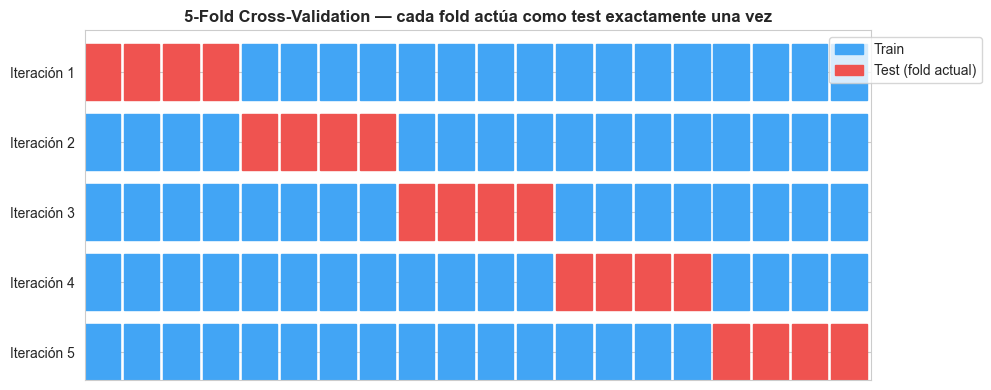

In [16]:
# Visualización del proceso: 5-Fold Cross-Validation
K = 5
n = 20  # observaciones simuladas para el diagrama

fig, ax = plt.subplots(figsize=(10, 4))

fold_size = n // K
for fold in range(K):
    for i in range(n):
        es_test = (fold * fold_size <= i < (fold + 1) * fold_size)
        color = '#EF5350' if es_test else '#42A5F5'
        ax.add_patch(plt.Rectangle((i, K - fold - 1), 0.9, 0.8, color=color))

ax.set_xlim(0, n)
ax.set_ylim(0, K)
ax.set_yticks([K - f - 0.6 for f in range(K)])
ax.set_yticklabels([f'Iteración {f+1}' for f in range(K)])
ax.set_xticks([])
ax.set_title('5-Fold Cross-Validation — cada fold actúa como test exactamente una vez', fontweight='bold')

patch_train = plt.Rectangle((0,0), 1, 1, color='#42A5F5', label='Train')
patch_test  = plt.Rectangle((0,0), 1, 1, color='#EF5350', label='Test (fold actual)')
ax.legend(handles=[patch_train, patch_test], loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()

> **Aclaración importante:** en la iteración *k*, el modelo **no entrena** con los datos que usa
> como validación en esa misma ronda — por eso la evaluación es honesta. Pero esos mismos datos
> **sí participan como entrenamiento en las otras K−1 iteraciones**. Cada dato pasa por ambos roles
> a lo largo del proceso completo, pero **nunca en la misma iteración**.


In [17]:
# Comparar: un solo split vs. K-Fold Cross-Validation, sobre los mismos datos
modelo_cv = make_pipeline(PolynomialFeatures(2), LinearRegression())

# Opción A: un único split train/test
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_sim, y_sim, test_size=0.2, random_state=7)
modelo_cv.fit(X_tr2, y_tr2)
error_split_unico = mean_squared_error(y_te2, modelo_cv.predict(X_te2))
print(f'Error con UN SOLO split (random_state=7): {error_split_unico:.1f}')

# Opción B: 5-Fold Cross-Validation
scores = cross_val_score(modelo_cv, X_sim, y_sim, cv=5, scoring='neg_mean_squared_error')
errores_cv = -scores
print(f'\nErrores en cada uno de los 5 folds: {errores_cv.round(1)}')
print(f'Error promedio (5-Fold CV): {errores_cv.mean():.1f}  ±  {errores_cv.std():.1f}')

Error con UN SOLO split (random_state=7): 67.1

Errores en cada uno de los 5 folds: [ 57.6  83.1 167.5 150.8 267.9]
Error promedio (5-Fold CV): 145.4  ±  73.6


### Variantes de Cross-Validation

| Variante | Descripción | Cuándo usar |
|---|---|---|
| **K-Fold** | K particiones aleatorias | Caso general, regresión |
| **Stratified K-Fold** | Igual que K-Fold, pero preservando la proporción de clases en cada fold | Clasificación, especialmente con clases desbalanceadas |
| **Leave-One-Out (LOO)** | Caso extremo: K = número de observaciones (cada fold tiene 1 solo dato) | Datasets muy pequeños; computacionalmente costoso con datasets grandes |


In [18]:
# StratifiedKFold: preserva la proporción de clases en cada fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Proporción de clase positiva en cada fold de test (StratifiedKFold):')
for i, (train_idx, test_idx) in enumerate(skf.split(X_desb, y_desb), 1):
    prop = y_desb[test_idx].mean()
    print(f'  Fold {i}: {prop:.2f}  (tamaño del fold: {len(test_idx)})')

print(f'\nProporción real en el dataset completo: {y_desb.mean():.2f}')
print('→ Cada fold mantiene aproximadamente la misma proporción de clases.')

Proporción de clase positiva en cada fold de test (StratifiedKFold):
  Fold 1: 0.10  (tamaño del fold: 20)
  Fold 2: 0.10  (tamaño del fold: 20)
  Fold 3: 0.10  (tamaño del fold: 20)
  Fold 4: 0.10  (tamaño del fold: 20)
  Fold 5: 0.10  (tamaño del fold: 20)

Proporción real en el dataset completo: 0.10
→ Cada fold mantiene aproximadamente la misma proporción de clases.


---
# 5. Curvas de Aprendizaje (Learning Curves)

**Pregunta que responde:** si mi modelo funciona mal, ¿el problema es que **necesito más datos**,  
o el problema es que **el modelo es demasiado simple/complejo** para el problema?

Una curva de aprendizaje grafica el error de train y de validación **a medida que aumenta el tamaño del conjunto de entrenamiento**.

| Patrón observado | Diagnóstico | Solución |
|---|---|---|
| Ambas curvas convergen en un error alto | Underfitting | Modelo más complejo, más variables |
| Gran brecha entre train (bajo) y validación (alto), que no cierra | Overfitting | Más datos, regularización, modelo más simple |
| Ambas curvas convergen en un error bajo | Buen ajuste | — |


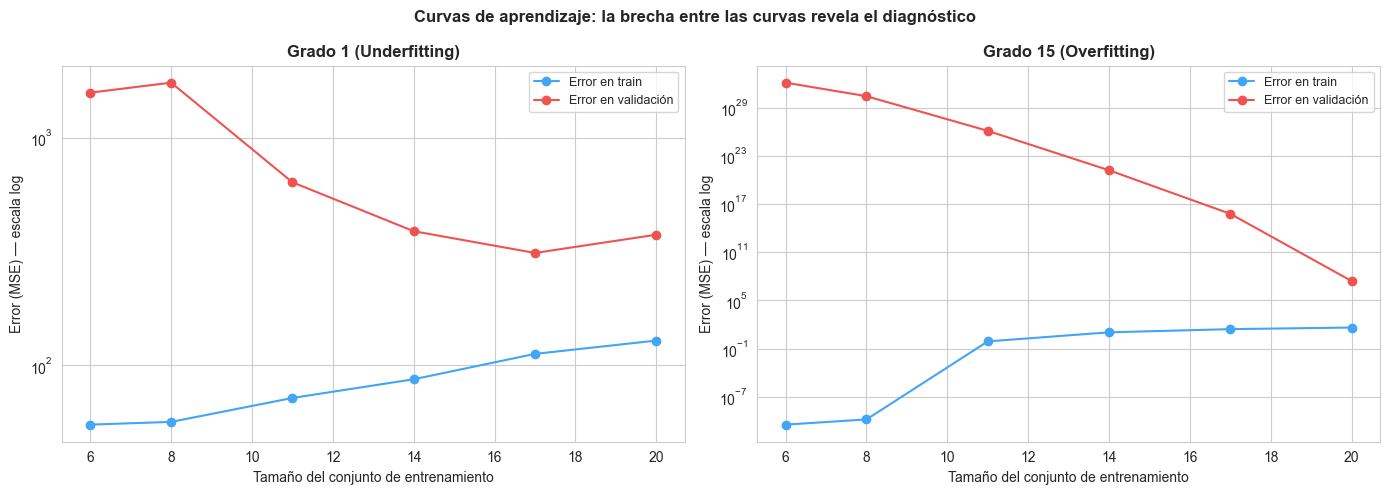

In [19]:
# Curva de aprendizaje para un modelo que subajusta (grado 1) vs uno que sobreajusta (grado 15)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, grado, titulo in zip(axes, [1, 15], ['Grado 1 (Underfitting)', 'Grado 15 (Overfitting)']):
    modelo_lc = make_pipeline(PolynomialFeatures(grado), LinearRegression())

    train_sizes, train_scores, val_scores = learning_curve(
        modelo_lc, X_sim, y_sim, cv=5,
        train_sizes=np.linspace(0.3, 1.0, 6),
        scoring='neg_mean_squared_error'
    )

    train_errors = -train_scores.mean(axis=1)
    val_errors   = -val_scores.mean(axis=1)

    ax.plot(train_sizes, train_errors, 'o-', color='#42A5F5', label='Error en train')
    ax.plot(train_sizes, val_errors,   'o-', color='#EF5350', label='Error en validación')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_yscale('log')
    ax.set_ylabel('Error (MSE) — escala log')
    ax.set_title(titulo, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Curvas de aprendizaje: la brecha entre las curvas revela el diagnóstico', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Resumen del Bloque A

| Concepto | Idea central |
|---|---|
| **Train/Test Split** | Nunca evaluar un modelo con los mismos datos que usó para aprender |
| **Overfitting/Underfitting** | El punto óptimo está en la complejidad que minimiza el error de test, no el de train |
| **Bias-Varianza** | Bias = modelo muy rígido (underfitting); Varianza = modelo muy sensible al dataset de entrenamiento (overfitting) |
| **Validation Set** | El test se toca **una sola vez**, al final; los hiperparámetros se ajustan con validation |
| **Cross-Validation** | Promediar K evaluaciones da una estimación más robusta que un solo split |
| **Learning Curves** | Diagnostican si el problema es falta de datos o complejidad del modelo |

### Flujo recomendado para el resto del curso

```
1. Preprocesar y transformar los datos (ya visto)
2. Dividir en train / test (estratificado si es clasificación)
3. Entrenar el modelo sobre train, usando Cross-Validation para elegir hiperparámetros
4. Evaluar UNA VEZ en test — esta es la métrica que se reporta
5. Si el desempeño no es satisfactorio: diagnosticar con curvas de aprendizaje
   (under/overfitting) antes de cambiar de algoritmo
```

> A partir de aquí, todos los notebooks de Clasificación y Regresión usarán este flujo como base.
